In [4]:
import pandas as pd
import joblib
import numpy as np

df_original = pd.read_csv('../data/feature_engineered_data.csv')
df_original = df_original.sort_values(by='date').reset_index(drop=True)
split_idx = int(len(df_original) * 0.8)
test_df_with_ids = df_original.iloc[split_idx:].copy()

X_test_scaled = pd.read_csv('../data/X_test_scaled.csv')
champion_model = joblib.load('../models/final_gradient_boost_model.pkl')

fraud_probabilities = champion_model.predict_proba(X_test_scaled)[:, 1]
test_df_with_ids['fraud_probability'] = fraud_probabilities

display(test_df_with_ids[['reviewerID', 'restaurantID', 'fraud_probability']].head(20))

,reviewerID,restaurantID,fraud_probability
1984,-D2rPtDjz5uOYEUs3FwiZA,d6UbRb9W5eA1yL-DuVZ8ug,0.823157
1985,_QgFJaqjG3cjf6viC-RHRQ,AqgG-1aD6JYj9D6OmBWO3w,0.981817
1986,2pIXbFALxpcntASFkOdgag,tCkwBTuEFvhuaBoEUWqbuQ,0.214453
1987,bqUcNkmsMzBNV27jh-kWIA,4wreIFjaPMppyEnzKHbozg,0.960935
1988,P0hK4o6d2Ie1M24btQ0PAA,dKcO9OQ44RPRlkWe-vToFA,0.056870
1989,0RAAywLbgwanuKkB3s2Sbg,0fFLUKl71vv3eNV2xhikEw,0.903293
1990,xgi3qtNPaFJqRIA02R3hdA,ibreTMGGaQSanZttUchjKg,0.971463
1991,skPF-lU8P0J8_TxSlFxGEw,8d_DiHWB-pjBVW3a7D8EWg,0.978418
1992,p1aT_pxqZPbR3b-dp2HsAg,euO3-H92LCivH2B0CQPlnw,0.511297
1993,9RE7AkKuE96f0bDSGg7cvg,o54U2VkQama8FI30qDkWvw,0.443775


In [5]:
reviewer_scores = test_df_with_ids.groupby('reviewerID').agg(
    suspicion_score=('fraud_probability', 'mean'),
    reviews_in_test=('fraud_probability', 'count')
).reset_index()

suspicious_reviewers = reviewer_scores.sort_values(
    by=['suspicion_score', 'reviews_in_test'], 
    ascending=[False, False]
)

display(suspicious_reviewers.head(10))



,reviewerID,suspicion_score,reviews_in_test
223,VKkVWmJIdq4fUB1ZXw7geg,0.990675,1
64,6AweaJd7xwfZ6Lxx2frmVw,0.990436,1
14,1754GNn_Dq0OZtLi6CD2hQ,0.989674,1
89,BfcDJKDc8Pcp3GXV-z1KrQ,0.988005,1
236,WqtZnNtjPLBfcG7XvInsKw,0.987778,1
297,eGFvBsuvKpFmILZd9b044Q,0.987088,1
130,Iwz0mdrjUEituIxmeW98rQ,0.985650,1
342,ju2g0avxFNOcR5DQPlfo5g,0.985606,1
81,9VPqES7l_j7VKW6GSVbkmQ,0.984858,1
129,IpVFQuWk4gEgQQ_XmzjeQQ,0.984754,1


In [8]:
!pip install networkx

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.1 MB 3.5 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 3.5 MB/s  0:00:00



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


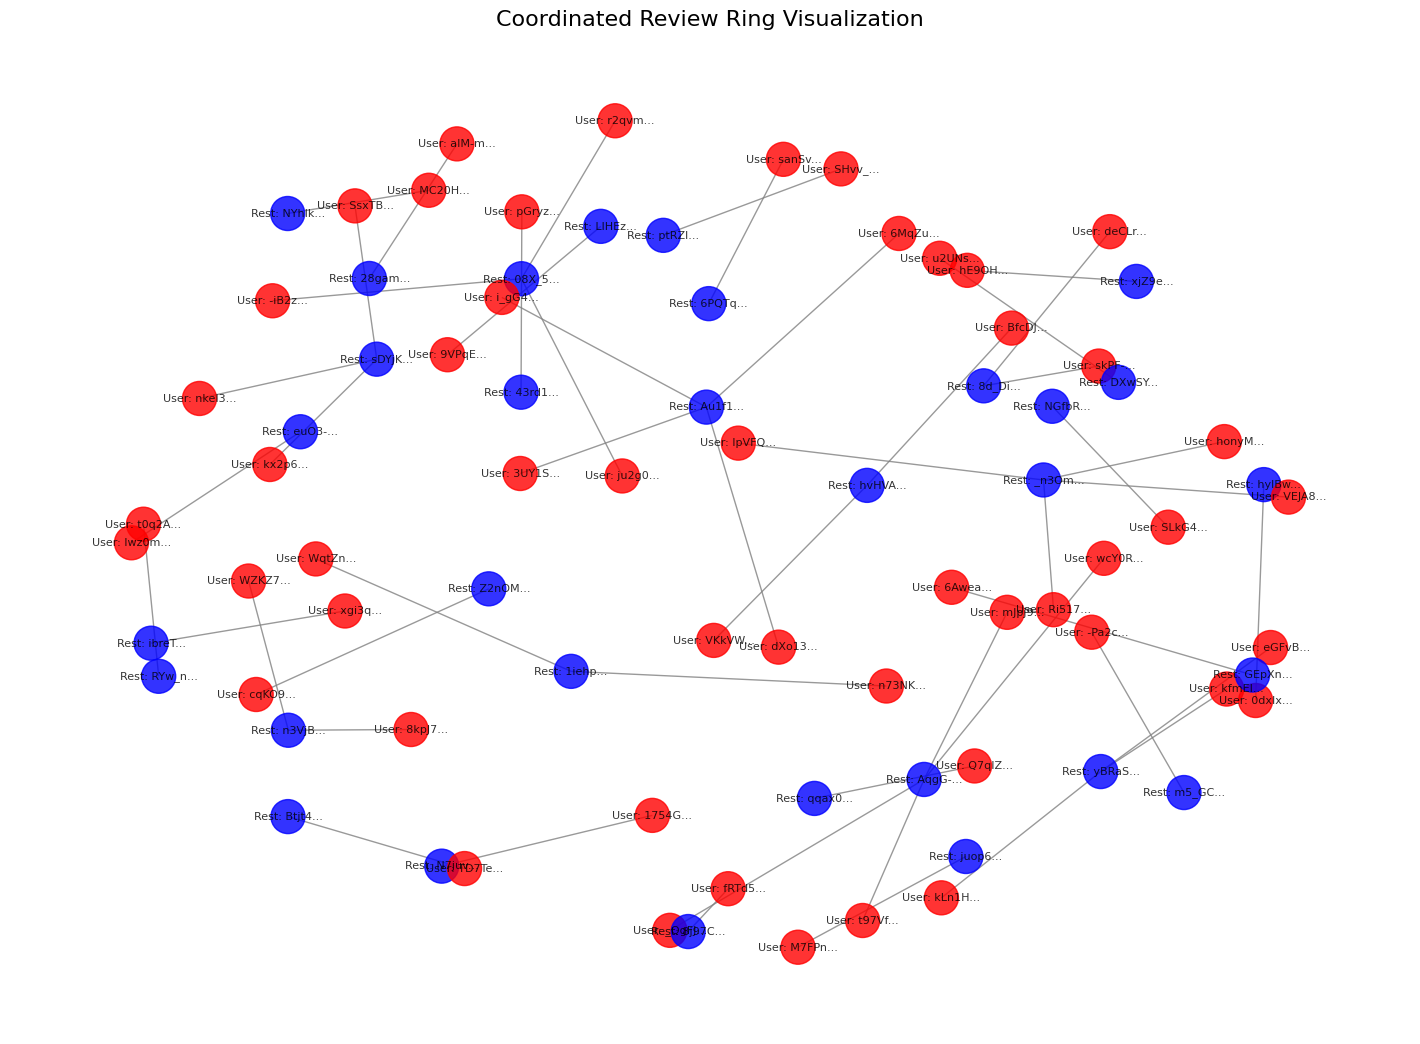

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

top_bots = suspicious_reviewers.head(50)['reviewerID'].tolist()
bot_network_df = test_df_with_ids[test_df_with_ids['reviewerID'].isin(top_bots)]

G = nx.Graph()

for _, row in bot_network_df.iterrows():
    user = f"User: {row['reviewerID'][:5]}..."
    restaurant = f"Rest: {row['restaurantID'][:5]}..."
    
    G.add_node(user, bipartite=0, color='red', type='user')
    G.add_node(restaurant, bipartite=1, color='blue', type='restaurant')
    G.add_edge(user, restaurant)

color_map = [x[1]['color'] for x in G.nodes(data=True)]
pos = nx.spring_layout(G, k=0.5, iterations=50) 

plt.figure(figsize=(14, 10))
nx.draw(G, pos, node_color=color_map, with_labels=True, font_size=8, node_size=600, edge_color='gray', alpha=0.8)
plt.title("Coordinated Review Ring Visualization", fontsize=16)
plt.show()